In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import nibabel as nib
import pydicom
import pandas as pd

print("Everything imported successfully!")


In [ ]:
import sys
print (sys.executable)


In [ ]:
import sys
!{sys.executable} -m pip install SimpleITK nibabel pydicom pandas matplotlib numpy


In [ ]:
from pathlib import Path
import SimpleITK as sitk

# CT folder path
ct_path = Path(
    "data/raw/manifest-1779461155262/QIN-BREAST/QIN-BREAST-01-0001/09-01-1991-NA-BREAST PRONE-21963/2.000000-CTAC-02377"
)

# PET folder path
pet_path = Path(
    "data/raw/manifest-1779461155262/QIN-BREAST/QIN-BREAST-01-0001/09-01-1991-NA-BREAST PRONE-21963/3.000000-PET AC 3DWB-32672"
)

print("CT path exists:", ct_path.exists())
print("PET path exists:", pet_path.exists())


In [ ]:
# Read CT DICOM series
ct_reader = sitk.ImageSeriesReader()

ct_dicom_names = ct_reader.GetGDCMSeriesFileNames(str(ct_path))
ct_reader.SetFileNames(ct_dicom_names)

ct_image = ct_reader.Execute()

print("CT image loaded successfully!")


In [ ]:
print("CT Size:", ct_image.GetSize())
print("CT Spacing:", ct_image.GetSpacing())
print("CT Origin:", ct_image.GetOrigin())
print("CT Direction:", ct_image.GetDirection())


In [ ]:
# Read PET DICOM series
pet_reader = sitk.ImageSeriesReader()

pet_dicom_names = pet_reader.GetGDCMSeriesFileNames(str(pet_path))
pet_reader.SetFileNames(pet_dicom_names)

pet_image = pet_reader.Execute()

print("PET image loaded successfully!")


In [ ]:
print("PET Size:", pet_image.GetSize())
print("PET Spacing:", pet_image.GetSpacing())
print("PET Origin:", pet_image.GetOrigin())
print("PET Direction:", pet_image.GetDirection())


In [ ]:
import matplotlib.pyplot as plt
import SimpleITK as sitk

ct_array = sitk.GetArrayFromImage(ct_image)
pet_array = sitk.GetArrayFromImage(pet_image)

print("CT array shape:", ct_array.shape)
print("PET array shape:", pet_array.shape)

In [ ]:
slice_index = ct_array.shape[0] // 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.title("CT middle slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pet_array[slice_index], cmap="hot")
plt.title("PET middle slice")
plt.axis("off")

plt.show()

In [ ]:
#As shown above, the CT image has a detailed anatomy and sharper edges, creating a high resolution anatomical image.
#The PET scan is blurrier and contains bright 'hotspots' which show the metabolic activity, creating a lower resolution functional image.
# Due to the different resolutions and image modalities, registration is needed. The purpose of this project is to align them properly

In [ ]:
#Now we are going to overlay the PET on CT:

In [ ]:
plt.figure(figsize=(8, 8))

# Show CT in grayscale
plt.imshow(ct_array[slice_index], cmap="gray")

# Overlay PET with transparency
plt.imshow(
    pet_array[slice_index],
    cmap="hot",
    alpha=0.4
)

plt.title("PET Overlay on CT")
plt.axis("off")

plt.show()

In [ ]:
#Now we are rebuilding the PET image so it has the same grid, size, spacing, origin and direction as the CT
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ct_image)
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0)

pet_resampled_to_ct = resampler.Execute(pet_image)

pet_resampled_array = sitk.GetArrayFromImage(pet_resampled_to_ct)

print("Resampled PET shape:", pet_resampled_array.shape)
print("CT shape:", ct_array.shape)

In [ ]:
#Overlaying again:
slice_index = ct_array.shape[0] // 2

plt.figure(figsize=(8, 8))

plt.imshow(ct_array[slice_index], cmap="gray")
plt.imshow(pet_resampled_array[slice_index], cmap="hot", alpha=0.4)

plt.title("PET Resampled into CT Space")
plt.axis("off")
plt.show()

In [ ]:
# Convert both images to Float32 first
fixed_image = sitk.Cast(ct_image, sitk.sitkFloat32)
moving_image = sitk.Cast(pet_image, sitk.sitkFloat32)

print("Fixed image dimension:", fixed_image.GetDimension())
print("Moving image dimension:", moving_image.GetDimension())
print("Fixed pixel type:", fixed_image.GetPixelIDTypeAsString())
print("Moving pixel type:", moving_image.GetPixelIDTypeAsString())

In [ ]:
# Initialize rigid transform
initial_transform = sitk.CenteredTransformInitializer(
    fixed_image,
    moving_image,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

print("Initial transform created successfully!")

In [ ]:
# Create registration method
registration_method = sitk.ImageRegistrationMethod()

# Similarity metric
registration_method.SetMetricAsMattesMutualInformation(
    numberOfHistogramBins=50
)

# Random sampling for speed
registration_method.SetMetricSamplingStrategy(
    registration_method.RANDOM
)

registration_method.SetMetricSamplingPercentage(0.01)

# Interpolator
registration_method.SetInterpolator(sitk.sitkLinear)

# Optimizer
registration_method.SetOptimizerAsRegularStepGradientDescent(
    learningRate=2.0,
    minStep=1e-4,
    numberOfIterations=100,
    gradientMagnitudeTolerance=1e-8
)

# Optimizer scaling
registration_method.SetOptimizerScalesFromPhysicalShift()

# Set transform
registration_method.SetInitialTransform(
    initial_transform,
    inPlace=False
)

print("Registration method created successfully!")

In [ ]:
# Execute rigid registration
final_transform = registration_method.Execute(
    fixed_image,
    moving_image
)

print("Rigid registration complete!")
print("Final metric value:", registration_method.GetMetricValue())
print(registration_method.GetOptimizerStopConditionDescription())

In [41]:
#Now we are created registered PET image: 
# Resample PET using the final rigid transform
pet_rigid = sitk.Resample(
    pet_image,
    ct_image,
    final_transform,
    sitk.sitkLinear,
    0.0,
    pet_image.GetPixelID()
)

pet_rigid_array = sitk.GetArrayFromImage(pet_rigid)

print("Rigid registered PET shape:", pet_rigid_array.shape)
print("CT shape:", ct_array.shape)

Rigid registered PET shape: (83, 512, 512)
CT shape: (83, 512, 512)


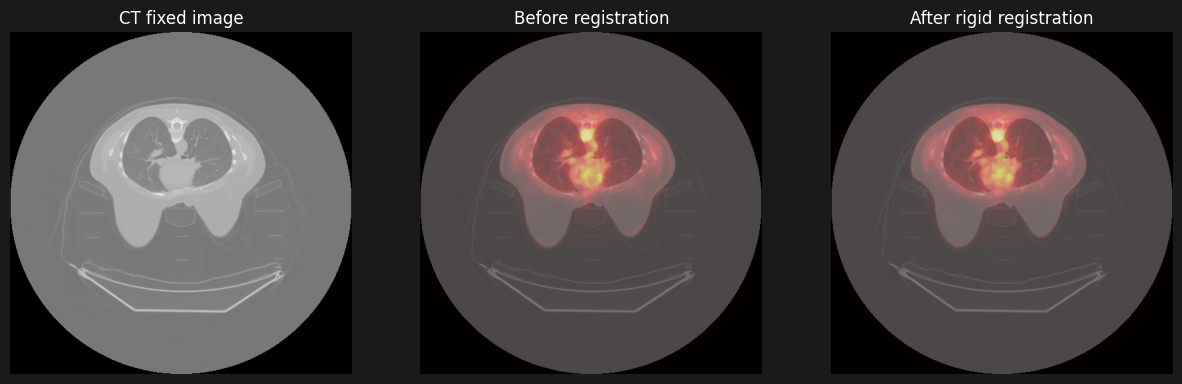

In [42]:
#Now the before vs after:
slice_index = ct_array.shape[0] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.title("CT fixed image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.imshow(pet_resampled_array[slice_index], cmap="hot", alpha=0.4)
plt.title("Before registration")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.imshow(pet_rigid_array[slice_index], cmap="hot", alpha=0.4)
plt.title("After rigid registration")
plt.axis("off")

plt.show()

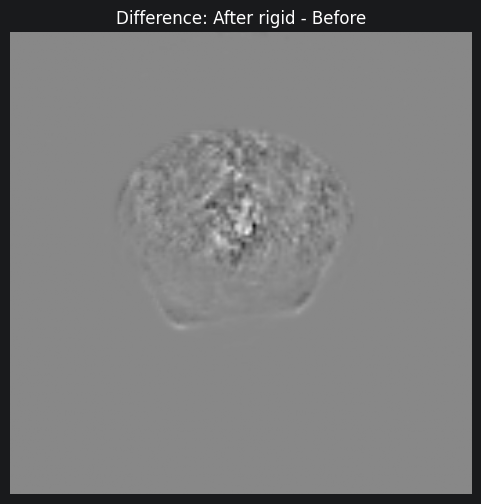

In [43]:
#The difference isn't so obvious, so :
difference = pet_rigid_array - pet_resampled_array

plt.figure(figsize=(6, 6))
plt.imshow(difference[slice_index], cmap="gray")
plt.title("Difference: After rigid - Before")
plt.axis("off")
plt.show()

In [44]:
print(final_transform)


itk::simple::CompositeTransform
 CompositeTransform (0x81ce84d80)
   RTTI typeinfo:   itk::CompositeTransform<double, 3u>
   Reference Count: 1
   Modified Time: 450779
   Debug: Off
   Object Name: 
   Observers: 
     none
   TransformQueue: 
   >>>>>>>>>
   Euler3DTransform (0x81c981200)
     RTTI typeinfo:   itk::Euler3DTransform<double>
     Reference Count: 1
     Modified Time: 450769
     Debug: Off
     Object Name: 
     Observers: 
       none
     Matrix: 
       0.999981 -0.00547974 -0.00274656 
       0.00548489 0.999983 0.00187159 
       0.00273625 -0.00188662 0.999994 
     Offset: [0.24749, 0.529805, -2.54062]
     Center: [0.683466, 0.683466, -166.57]
     Translation: [0.701226, 0.221793, -2.53912]
     Inverse: 
       0.999981 0.00548489 0.00273625 
       -0.00547974 0.999983 -0.00188662 
       -0.00274656 0.00187159 0.999994 
     Singular: 0
     AngleX: -0.00188662
     AngleY: -0.00273626
     AngleZ: 0.00547978
     ComputeZYX: Off
   TransformsToOptimizeFl

In [45]:
output_path = "data/registered/patient_001_pet_rigid.nii.gz"

sitk.WriteImage(pet_rigid, output_path)

print("Saved rigid registered PET to:", output_path)

Saved rigid registered PET to: data/registered/patient_001_pet_rigid.nii.gz


In [48]:
import importlib
import src.registration_rigid

importlib.reload(src.registration_rigid)

from src.registration_rigid import rigid_registration

In [49]:
registered_pet, transform = rigid_registration(ct_image, pet_image)

print("Rigid registration function worked!")
print(transform)

Rigid registration function worked!
itk::simple::CompositeTransform
 CompositeTransform (0x81ce85080)
   RTTI typeinfo:   itk::CompositeTransform<double, 3u>
   Reference Count: 1
   Modified Time: 887399
   Debug: Off
   Object Name: 
   Observers: 
     none
   TransformQueue: 
   >>>>>>>>>
   Euler3DTransform (0x81c981000)
     RTTI typeinfo:   itk::Euler3DTransform<double>
     Reference Count: 1
     Modified Time: 887389
     Debug: Off
     Object Name: 
     Observers: 
       none
     Matrix: 
       0.999959 -0.00828425 -0.00356071 
       0.00827823 0.999964 -0.00170156 
       0.00357468 0.00167202 0.999992 
     Offset: [-0.273873, 0.313422, -3.69965]
     Center: [0.683466, 0.683466, -166.57]
     Translation: [0.313545, 0.602484, -3.69476]
     Inverse: 
       0.999959 0.00827823 0.00357468 
       -0.00828425 0.999964 0.00167202 
       -0.00356071 -0.00170156 0.999992 
     Singular: 0
     AngleX: 0.00167202
     AngleY: -0.00357469
     AngleZ: 0.00828435
     Comp

In [50]:
sitk.WriteImage(
    registered_pet,
    "data/registered/patient_001_pet_rigid_from_function.nii.gz"
)

print("Saved registered PET from function!")

Saved registered PET from function!


In [51]:
from src.registration_affine import affine_registration

affine_pet, affine_transform = affine_registration(
    ct_image,
    pet_image
)

print("Affine registration complete!")
print(affine_transform)

Affine registration complete!
itk::simple::CompositeTransform
 CompositeTransform (0x81ce84f00)
   RTTI typeinfo:   itk::CompositeTransform<double, 3u>
   Reference Count: 1
   Modified Time: 1324288
   Debug: Off
   Object Name: 
   Observers: 
     none
   TransformQueue: 
   >>>>>>>>>
   AffineTransform (0x81995cfc0)
     RTTI typeinfo:   itk::AffineTransform<double, 3u>
     Reference Count: 1
     Modified Time: 1324278
     Debug: Off
     Object Name: 
     Observers: 
       none
     Matrix: 
       0.67727 -0.0120443 0.0447791 
       -0.00452119 0.709179 0.0289709 
       -0.00380695 -0.149976 1.54027 
     Offset: [7.92454, 51.9381, -38.0733]
     Center: [0.683466, 0.683466, -166.57]
     Translation: [0.236882, 46.9106, -128.171]
     Inverse: 
       1.47638 0.0159337 -0.0432214 
       0.00922651 1.4046 -0.0266873 
       0.00454743 0.136805 0.646532 
     Singular: 0
   TransformsToOptimizeFlags: 
           1 
   TransformsToOptimizeQueue: 
   PreviousTransformsToOpti

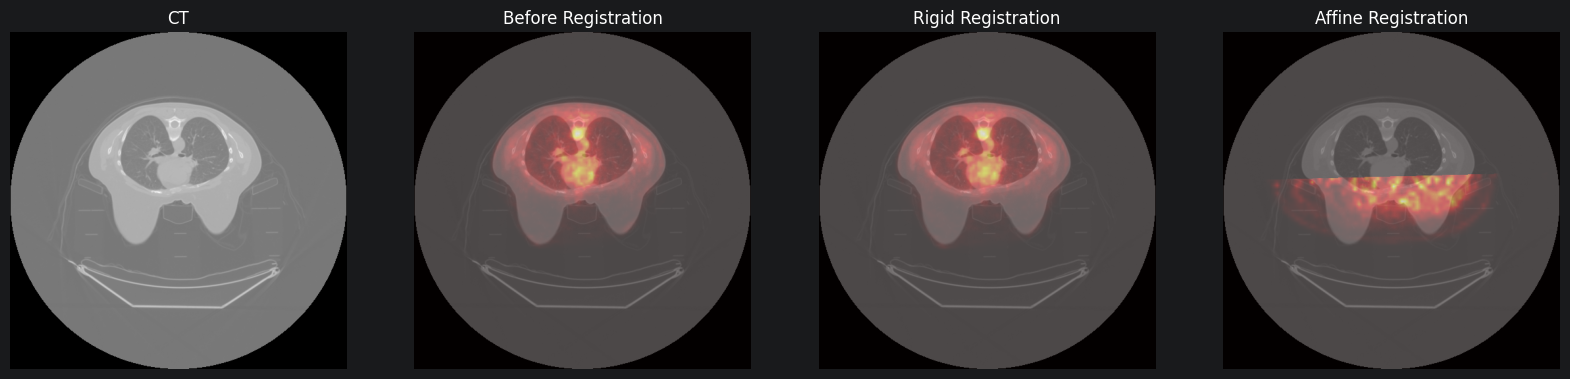

In [52]:
affine_array = sitk.GetArrayFromImage(affine_pet)

slice_index = ct_array.shape[0] // 2

plt.figure(figsize=(20, 5))

# CT only
plt.subplot(1, 4, 1)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.title("CT")
plt.axis("off")

# Before registration
plt.subplot(1, 4, 2)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.imshow(pet_resampled_array[slice_index], cmap="hot", alpha=0.4)
plt.title("Before Registration")
plt.axis("off")

# Rigid
plt.subplot(1, 4, 3)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.imshow(pet_rigid_array[slice_index], cmap="hot", alpha=0.4)
plt.title("Rigid Registration")
plt.axis("off")

# Affine
plt.subplot(1, 4, 4)
plt.imshow(ct_array[slice_index], cmap="gray")
plt.imshow(affine_array[slice_index], cmap="hot", alpha=0.4)
plt.title("Affine Registration")
plt.axis("off")

plt.show()